# Тематическое моделирование LDA

Представим рецепты как bag of ingredients, выделим скрытые темы и сравним распределение тем с известными типами кухни.

In [1]:
import json
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

sns.set_theme(style="whitegrid")

In [2]:
with open("recipes.json", encoding="utf-8") as file:
    recipes = json.load(file)

data = pd.DataFrame(recipes)
data["document"] = data["ingredients"].map(lambda ingredients: " ".join(item.replace(" ", "_") for item in ingredients))
display(data.head())
display(data["cuisine"].value_counts().to_frame("recipes"))

,cuisine,ingredients,document
0,italian,"[tomato, basil, olive oil, garlic, pasta]",tomato basil olive_oil garlic pasta
1,italian,"[parmesan, risotto rice, mushroom, butter, onion]",parmesan risotto_rice mushroom butter onion
2,italian,"[mozzarella, tomato, basil, flour, olive oil]",mozzarella tomato basil flour olive_oil
3,italian,"[pasta, egg, parmesan, bacon, black pepper]",pasta egg parmesan bacon black_pepper
4,italian,"[tomato, oregano, garlic, beef, pasta]",tomato oregano garlic beef pasta


,recipes
cuisine,
italian,5
mexican,5
indian,5
japanese,5
french,5


## Обучение LDA

In [3]:
vectorizer = CountVectorizer(binary=True)
matrix = vectorizer.fit_transform(data["document"])
lda = LatentDirichletAllocation(n_components=5, learning_method="batch", max_iter=100, random_state=42)
document_topics = lda.fit_transform(matrix)
terms = vectorizer.get_feature_names_out()

topic_rows = []
for topic_index, weights in enumerate(lda.components_):
    top_terms = terms[weights.argsort()[-8:][::-1]]
    topic_rows.append({"topic": f"topic_{topic_index}", "top_ingredients": ", ".join(top_terms)})

pd.DataFrame(topic_rows)

,topic,top_ingredients
0,topic_0,"tomato, cream, flour, olive_oil, basil, turmer..."
1,topic_1,"butter, pasta, egg, beef, parmesan, mushroom, ..."
2,topic_2,"chili, beans, onion, lime, corn_tortilla, avoc..."
3,topic_3,"soy_sauce, rice, green_onion, nori, garlic, se..."
4,topic_4,"chicken, cumin, onion, ginger, rice, garlic, s..."


## Темы документов

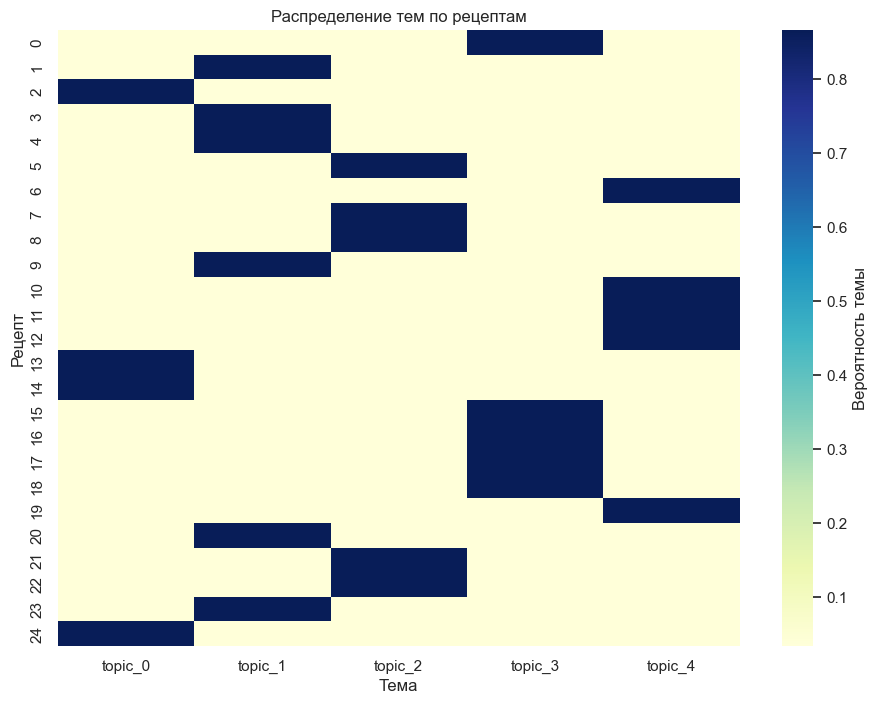

In [4]:
topic_frame = pd.DataFrame(document_topics, columns=[f"topic_{index}" for index in range(5)])
topic_frame["cuisine"] = data["cuisine"]

plt.figure(figsize=(11, 8))
sns.heatmap(topic_frame.drop(columns="cuisine"), cmap="YlGnBu", cbar_kws={"label": "Вероятность темы"})
plt.title("Распределение тем по рецептам")
plt.xlabel("Тема")
plt.ylabel("Рецепт")
plt.show()

## Связь тем с кухнями

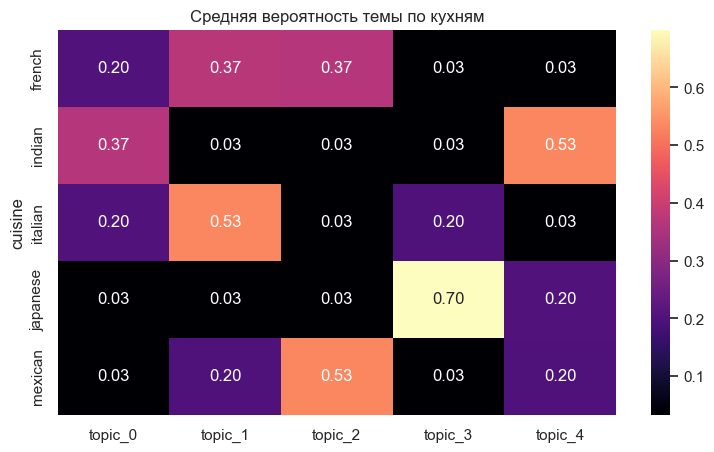

,topic_0,topic_1,topic_2,topic_3,topic_4
cuisine,,,,,
french,0.200128,0.366631,0.366267,0.033393,0.033581
indian,0.366237,0.033555,0.033624,0.033425,0.533160
italian,0.200200,0.532946,0.033588,0.199711,0.033555
japanese,0.033368,0.033419,0.033347,0.699869,0.199997
mexican,0.033715,0.199786,0.533140,0.033410,0.199948


In [5]:
cuisine_topics = topic_frame.groupby("cuisine").mean()

plt.figure(figsize=(9, 5))
sns.heatmap(cuisine_topics, annot=True, fmt=".2f", cmap="magma")
plt.title("Средняя вероятность темы по кухням")
plt.show()

cuisine_topics

## Вывод

LDA находит совместно встречающиеся ингредиенты без использования целевых меток. Темы можно интерпретировать по словам с наибольшими весами, но качество зависит от корпуса, словаря и выбранного числа тем.

## Расширенный анализ тематической модели

In [6]:
import numpy as np

### Статистика корпуса и частотность ингредиентов

,value
documents,25.000000
cuisines,5.000000
vocabulary,65.000000
mean_ingredients,5.000000
matrix_density,0.076923


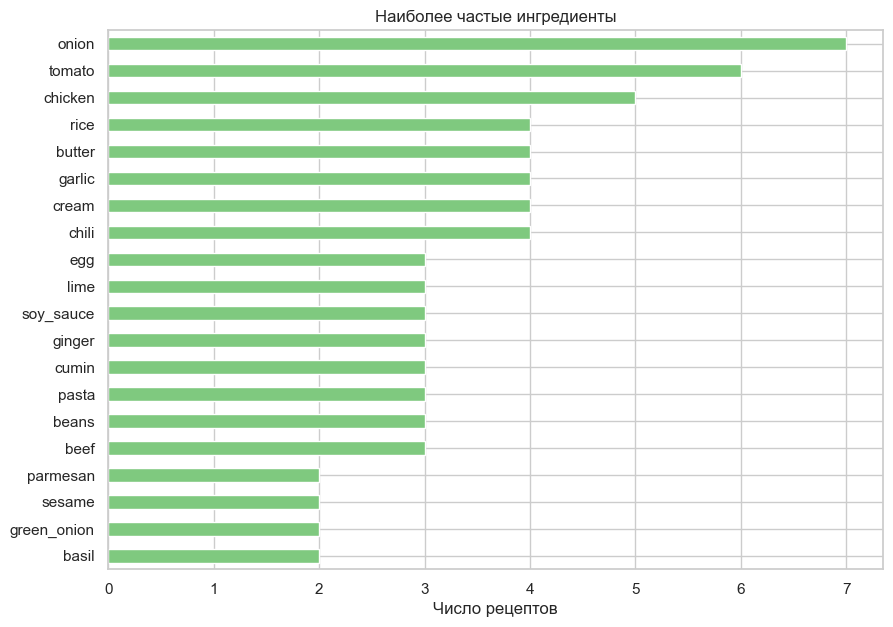

In [7]:
corpus_stats = pd.Series({
    "documents": len(data),
    "cuisines": data["cuisine"].nunique(),
    "vocabulary": matrix.shape[1],
    "mean_ingredients": data["ingredients"].map(len).mean(),
    "matrix_density": matrix.nnz / (matrix.shape[0] * matrix.shape[1]),
})
display(corpus_stats.to_frame("value"))

ingredient_frequency = pd.Series(np.asarray(matrix.sum(axis=0)).ravel(), index=terms).sort_values(ascending=False)
ingredient_frequency.head(20).sort_values().plot.barh(figsize=(10, 7), color="#7fc97f")
plt.title("Наиболее частые ингредиенты")
plt.xlabel("Число рецептов")
plt.show()

### Выбор числа тем по perplexity

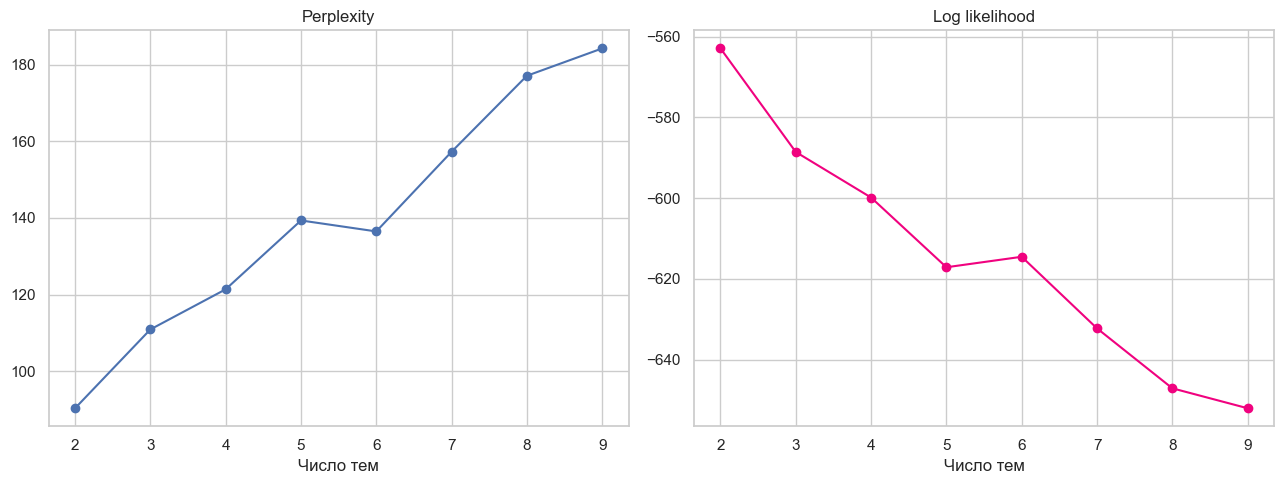

In [8]:
topic_count_rows = []
for topics_count in range(2, 10):
    candidate = LatentDirichletAllocation(
        n_components=topics_count,
        learning_method="batch",
        max_iter=100,
        random_state=42,
    )
    candidate.fit(matrix)
    topic_count_rows.append({
        "topics": topics_count,
        "perplexity": candidate.perplexity(matrix),
        "log_likelihood": candidate.score(matrix),
    })

topic_count_results = pd.DataFrame(topic_count_rows)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(topic_count_results["topics"], topic_count_results["perplexity"], marker="o")
axes[0].set_title("Perplexity")
axes[0].set_xlabel("Число тем")
axes[1].plot(topic_count_results["topics"], topic_count_results["log_likelihood"], marker="o", color="#f0027f")
axes[1].set_title("Log likelihood")
axes[1].set_xlabel("Число тем")
plt.tight_layout()
plt.show()

### Веса ингредиентов в темах

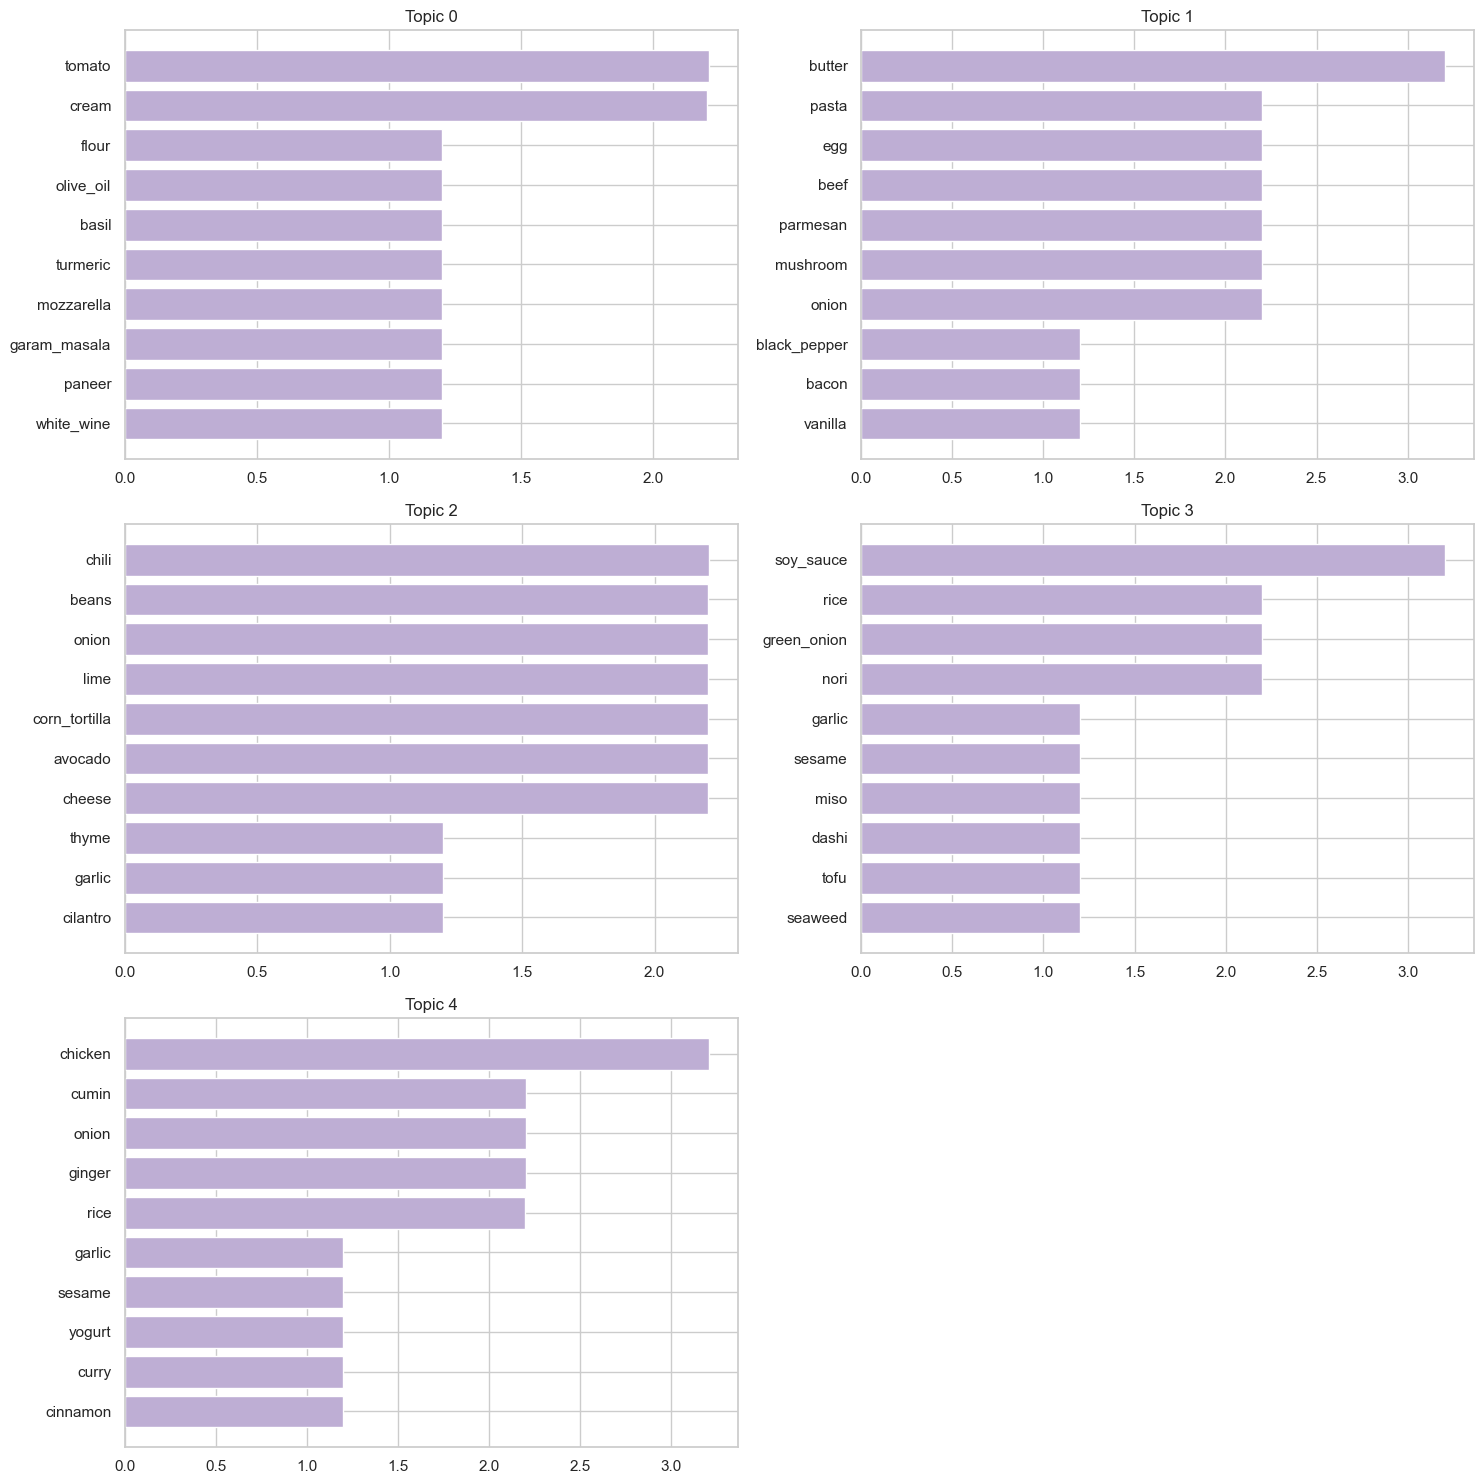

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
for topic_index, axis in enumerate(axes.ravel()):
    if topic_index >= lda.n_components:
        axis.axis("off")
        continue
    weights = lda.components_[topic_index]
    top_indices = weights.argsort()[-10:]
    axis.barh(terms[top_indices], weights[top_indices], color="#beaed4")
    axis.set_title(f"Topic {topic_index}")
plt.tight_layout()
plt.show()

### Доминирующие темы

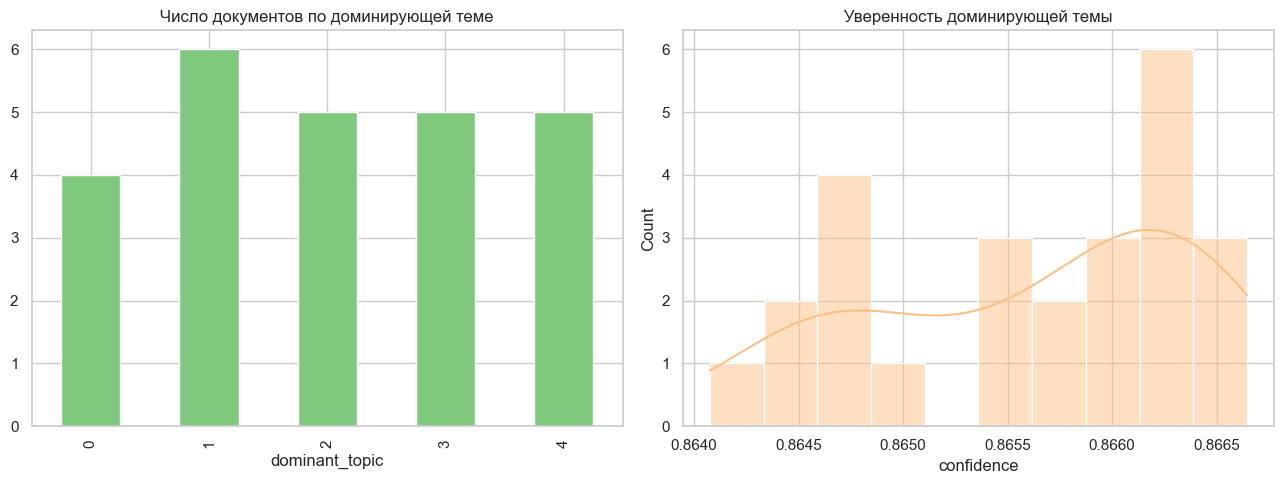

In [10]:
topic_frame["dominant_topic"] = document_topics.argmax(axis=1)
topic_frame["confidence"] = document_topics.max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
topic_frame["dominant_topic"].value_counts().sort_index().plot.bar(ax=axes[0], color="#7fc97f")
axes[0].set_title("Число документов по доминирующей теме")
sns.histplot(topic_frame["confidence"], bins=10, kde=True, ax=axes[1], color="#fdc086")
axes[1].set_title("Уверенность доминирующей темы")
plt.tight_layout()
plt.show()

### Темы и известные кухни

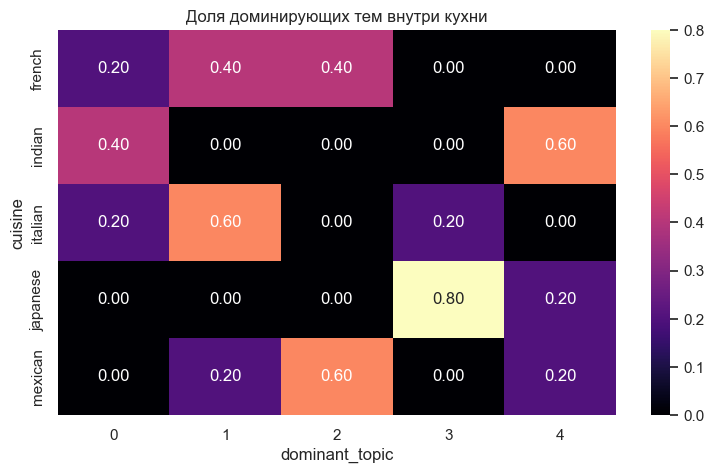

dominant_topic,0,1,2,3,4
cuisine,,,,,
french,0.2,0.4,0.4,0.0,0.0
indian,0.4,0.0,0.0,0.0,0.6
italian,0.2,0.6,0.0,0.2,0.0
japanese,0.0,0.0,0.0,0.8,0.2
mexican,0.0,0.2,0.6,0.0,0.2


In [11]:
cuisine_topic_table = pd.crosstab(
    topic_frame["cuisine"],
    topic_frame["dominant_topic"],
    normalize="index",
)

plt.figure(figsize=(9, 5))
sns.heatmap(cuisine_topic_table, annot=True, fmt=".2f", cmap="magma")
plt.title("Доля доминирующих тем внутри кухни")
plt.show()

cuisine_topic_table

### Репрезентативные рецепты

In [12]:
representative_rows = []
for topic_index in range(lda.n_components):
    best_document_index = int(np.argmax(document_topics[:, topic_index]))
    representative_rows.append({
        "topic": topic_index,
        "cuisine": data.loc[best_document_index, "cuisine"],
        "ingredients": ", ".join(data.loc[best_document_index, "ingredients"]),
        "topic_probability": document_topics[best_document_index, topic_index],
    })

pd.DataFrame(representative_rows)

,topic,cuisine,ingredients,topic_probability
0,0,italian,"mozzarella, tomato, basil, flour, olive oil",0.865899
1,1,italian,"pasta, egg, parmesan, bacon, black pepper",0.866468
2,2,mexican,"corn tortilla, beans, chili, lime, avocado",0.866341
3,3,japanese,"miso, tofu, seaweed, dashi, green onion",0.866645
4,4,indian,"chicken, curry, cumin, ginger, yogurt",0.866385


### Энтропия распределения тем

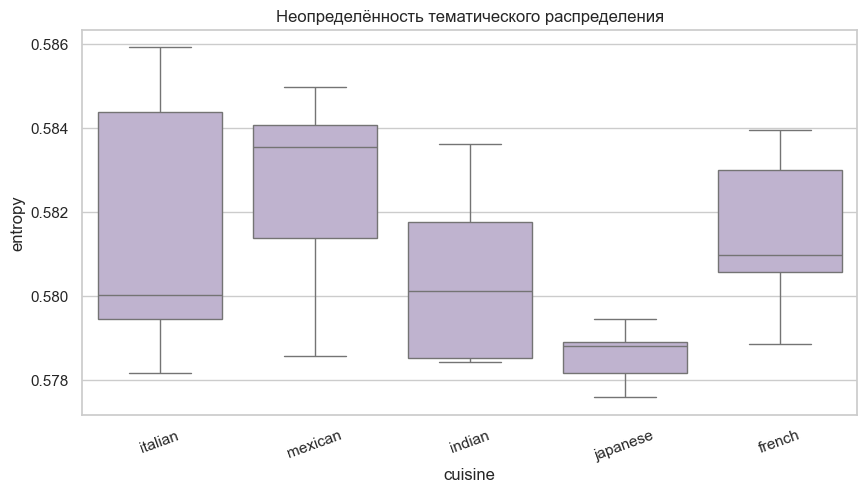

In [13]:
topic_entropy = -(document_topics * np.log(document_topics + 1e-12)).sum(axis=1)
entropy_frame = pd.DataFrame({"entropy": topic_entropy, "cuisine": data["cuisine"]})

plt.figure(figsize=(10, 5))
sns.boxplot(data=entropy_frame, x="cuisine", y="entropy", color="#beaed4")
plt.title("Неопределённость тематического распределения")
plt.xticks(rotation=20)
plt.show()

### Итог расширенного анализа

Perplexity помогает сравнивать число тем, но не гарантирует человеческую интерпретируемость. Поэтому модель нужно дополнять таблицами top-слов, репрезентативными документами, распределением уверенности и сравнением с доступной внешней разметкой.